In [81]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns
import scipy.stats as stats
import joblib
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

### Loading cleaned data set

In [82]:
file_path = "cleaned_dataset.csv"

data = pd.read_csv(file_path)
data

,Date,Service,Gare de départ,Gare d'arrivée,Durée moyenne du trajet,Nombre de circulations prévues,Nombre de trains annulés,Nombre de trains en retard au départ,Retard moyen des trains en retard au départ,Retard moyen de tous les trains au départ,...,Nombre trains en retard > 60min,Prct retard pour causes externes,Prct retard pour cause infrastructure,Prct retard pour cause gestion trafic,Prct retard pour cause matériel roulant,Prct retard pour cause gestion en gare et réutilisation de matériel,"Prct retard pour cause prise en compte voyageurs (affluence, gestions PSH, correspondances)",year,month,cancellation_rate
0,2018-01-01,NATIONAL,BORDEAUX SAINT JEAN,PARIS MONTPARNASSE,141.00,870.0,5.0,289.0,11.247809,3.693179,...,8.0,36.134454,31.092437,10.924370,15.966387,5.882353,0.840336,2018,1,0.005747
1,2018-01-01,NATIONAL,LE MANS,PARIS MONTPARNASSE,56.00,406.0,1.0,213.0,8.479969,4.567119,...,4.0,20.000000,35.000000,16.666667,16.666667,8.333333,3.333333,2018,1,0.002463
2,2018-01-01,NATIONAL,PARIS MONTPARNASSE,LA ROCHELLE VILLE,166.00,226.0,0.0,21.0,6.239683,0.286283,...,1.0,22.222222,27.777778,16.666667,16.666667,5.555556,11.111111,2018,1,0.000000
3,2018-01-01,NATIONAL,PARIS MONTPARNASSE,NANTES,216.21,508.0,3.0,71.0,7.235211,0.980000,...,3.0,33.333333,22.222222,16.666667,20.370370,5.555556,1.851852,2018,1,0.005906
4,2018-01-01,NATIONAL,POITIERS,PARIS MONTPARNASSE,94.00,472.0,4.0,224.0,6.784673,3.229701,...,0.0,15.789474,45.614035,18.750000,15.789474,1.754386,1.754386,2018,1,0.008475
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11699,2018-11-01,NATIONAL,SAINT ETIENNE CHATEAUCREUX,PARIS LYON,168.00,113.0,1.0,19.0,5.662281,0.854762,...,2.0,21.052632,36.842105,5.263158,21.052632,10.526316,5.263158,2018,11,0.008850
11700,2021-05-01,NaN,PARIS MONTPARNASSE,NANTES,138.00,470.0,29.0,48.0,4.225694,0.151738,...,0.0,22.222222,0.000000,11.111111,33.333333,0.000000,33.333333,2021,5,0.061702
11701,2018-03-01,NaN,PERPIGNAN,PARIS LYON,305.00,163.0,1.0,63.0,8.189418,3.216770,...,7.0,57.142857,14.285714,14.285714,14.285714,0.000000,0.000000,2018,3,0.006135
11702,2019-02-01,NATIONAL,NICE VILLE,PARIS LYON,357.00,159.0,4.0,32.0,6.806250,1.463978,...,5.0,18.181818,36.363636,24.242424,12.121212,9.090909,0.000000,2019,2,0.025157


### Outlier removal

In [83]:
target = "Retard moyen de tous les trains à l'arrivée"

q_low = data[target].quantile(0.01)
q_high = data[target].quantile(0.99)

before = len(data)
data = data[(data[target] >= q_low) & (data[target] <= q_high)]
after = len(data)

print(f"Rows before outlier removal: {before}")
print(f"Rows after outlier removal:  {after}")
print(f"Outliers removed: {before - after}")
print(f"Target range: {data[target].min():.2f} to {data[target].max():.2f}")

Rows before outlier removal: 11704
Rows after outlier removal:  11474
Outliers removed: 230
Target range: 0.00 to 20.34


outlier removal was needed because the target variable contained physically impossible values such as -472 and +92, so we removed the bottom and top 1% of values without reducing the dataset, allowing the model to learn from real patterns and improving our r2 result from 0.06 to 0.81

### Missing Values fix + Infinity values fix

In [84]:
data["Service"] = data["Service"].fillna(data["Service"].mode()[0])
data["cancellation_rate"] = data["cancellation_rate"].fillna(data["cancellation_rate"].median())

data = data.replace([np.inf, -np.inf], np.nan)
data = data.fillna(data.median(numeric_only=True))

print("Missing values after fix:", data.isnull().sum().sum())
print("Infinity values after fix:", np.isinf(data.select_dtypes(include=np.number).values).sum())

Missing values after fix: 0
Infinity values after fix: 0


/var/folders/1k/1vk3t49j73b6527f6tdl9cr80000gn/T/ipykernel_50407/2359546673.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data["Service"] = data["Service"].fillna(data["Service"].mode()[0])
/var/folders/1k/1vk3t49j73b6527f6tdl9cr80000gn/T/ipykernel_50407/2359546673.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data["cancellation_rate"] = data["cancellation_rate"].fillna(data["cancellation_rate"].median())


some columns still contain missing values or infinity values (caused by cancellation_rate, division by 0), so we replace them with the mode, numeric values with the median, and replace any infinity values with NaN before filling

### Define Features X and Target y

In [85]:
y = data["Retard moyen de tous les trains à l'arrivée"]

X = data[[
    "Service",
    "Gare de départ",
    "Gare d'arrivée",
    "Durée moyenne du trajet",
    "Nombre de circulations prévues",
    "Nombre de trains annulés",
    "Nombre de trains en retard au départ",
    "Prct retard pour causes externes",
    "Prct retard pour cause infrastructure",
    "Prct retard pour cause gestion trafic",
    "Prct retard pour cause matériel roulant",
    "Prct retard pour cause gestion en gare et réutilisation de matériel",
    "Prct retard pour cause prise en compte voyageurs (affluence, gestions PSH, correspondances)",
    "year",
    "month",
    "cancellation_rate"
]]

print("X shape:", X.shape)
print("y shape:", y.shape)
print("\nMissing values in X:")
print(X.isnull().sum()[X.isnull().sum() > 0])
print("\nMissing values in y:", y.isnull().sum())

X shape: (11474, 16)
y shape: (11474,)

Missing values in X:
Series([], dtype: int64)

Missing values in y: 0


we define y where y is the target variable (average arrival delay in minutes) and we also define X where X is the 16 input features the model uses to make predictions

### Encode categorical variables

In [86]:
le_service = LabelEncoder()
le_depart = LabelEncoder()
le_arrivee = LabelEncoder()

X = X.copy()
X["Service"] = le_service.fit_transform(X["Service"])
X["Gare de départ"] = le_depart.fit_transform(X["Gare de départ"])
X["Gare d'arrivée"] = le_arrivee.fit_transform(X["Gare d'arrivée"])
joblib.dump(le_service, "le_service.joblib")
joblib.dump(le_depart, "le_depart.joblib")
joblib.dump(le_arrivee, "le_arrivee.joblib")

print(X[["Service", "Gare de départ", "Gare d'arrivée"]].head())

   Service  Gare de départ  Gare d'arrivée
0        1               9              39
1        1              23              39
2        1              39              19
3        1              39              34
4        1              43              39


we  use LabelEncoder which assigns a unique integer to each unique category, and save each category as a .joblib so that the dashboard can use them

### Train / Test Split

In [87]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))

Training rows: 9179
Testing rows: 2295


we split the data into 80% training and 20% testing.
we use random_state = 42 to ensure that the split is reproducible everything we run this notebook and therefore we get the same result everytime.

### Feature Scaling  (Linear Regression)

In [88]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


linear regression is sensitive to feature scaling, so we implemented standard scaler to transform every feature to have mean=0 and standard deviation=1 putting all features on equal footing. we use fit_transform on training data and transform` only on test data, 
never fitting on test data to avoid data leakage

### Baseline model

In [89]:
mean_prediction = y_train.mean()
baseline_preds = np.full(len(y_test), mean_prediction)
baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_preds))
print(f"Baseline RMSE: {baseline_rmse:.2f} minutes")

Baseline RMSE: 3.51 minutes


we establish a naive baseline that always predicts the mean delay for every single train, this is the minimum performance bar (our models if efficient should beat this)

### Linear Regression

In [95]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
from math import sqrt

lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

y_pred = lr.predict(X_test_scaled)

rmse = sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"RMSE: {rmse:.2f} minutes")
print(f"MAE:  {mae:.2f} minutes")
print(f"R2:   {r2:.4f}")



RMSE: 3.10 minutes
MAE:  2.34 minutes
R2:   0.2231


Linear regression is our first model it finds the best-fitting straight-line relationship between the features and the target variable,
it assumes the relationship between features and delay is linear which is not the case in real-world data like in our case.

### Random Forest

Random forest is our main model, it builds 200 independent decision trees, each trained on a random subset of the data and features ( we 
set the random_state to 42). The final prediction is the average of the 200 trees, therefore this approach handles non-linear patterns and interactions between features much better than Linear Regression

In [91]:
X_rf = data[[
    "Service",
    "Gare de départ",
    "Gare d'arrivée",
    "Durée moyenne du trajet",
    "Nombre de circulations prévues",
    "Nombre de trains annulés",
    "Nombre de trains en retard au départ",
    "Retard moyen des trains en retard au départ",
    "Retard moyen de tous les trains au départ",
    "Nombre trains en retard > 15min",
    "Nombre trains en retard > 30min",
    "Nombre trains en retard > 60min",
    "Prct retard pour causes externes",
    "Prct retard pour cause infrastructure",
    "Prct retard pour cause gestion trafic",
    "Prct retard pour cause matériel roulant",
    "Prct retard pour cause gestion en gare et réutilisation de matériel",
    "Prct retard pour cause prise en compte voyageurs (affluence, gestions PSH, correspondances)",
    "year",
    "month",
    "cancellation_rate"
]]

y_rf = data["Retard moyen de tous les trains à l'arrivée"]
X_rf = pd.get_dummies(X_rf, columns=["Service", "Gare de départ", "Gare d'arrivée"])

X_rf_train, X_rf_test, y_rf_train, y_rf_test = train_test_split(
    X_rf, y_rf, test_size=0.2, random_state=42
)

rf = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1, min_samples_leaf=2)
rf.fit(X_rf_train, y_rf_train)
rf_preds = rf.predict(X_rf_test)

rf_rmse = sqrt(mean_squared_error(y_rf_test, rf_preds))
rf_mae = mean_absolute_error(y_rf_test, rf_preds)
rf_r2 = r2_score(y_rf_test, rf_preds)

print(f"RMSE: {rf_rmse:.2f} minutes")
print(f"MAE:  {rf_mae:.2f} minutes")
print(f"R²:   {rf_r2:.4f}")

RMSE: 1.52 minutes
MAE:  1.05 minutes
R²:   0.8122


### Model comparison

In [92]:
results = pd.DataFrame({
    "Model": ["Baseline", "Linear Regression", "Random Forest"],
    "RMSE": [3.51, 3.10, 1.52],
    "MAE": [None, 2.34, 1.05],
    "R²": [None, 0.2231, 0.8122]
})
print(results.to_string(index=False))

            Model  RMSE  MAE     R²
         Baseline  3.51  NaN    NaN
Linear Regression  3.10 2.34 0.2231
    Random Forest  1.52 1.05 0.8122


### Feature importance score interpretation

/var/folders/1k/1vk3t49j73b6527f6tdl9cr80000gn/T/ipykernel_50407/3163538940.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_features.values, y=top_features.index, palette="Blues_r")


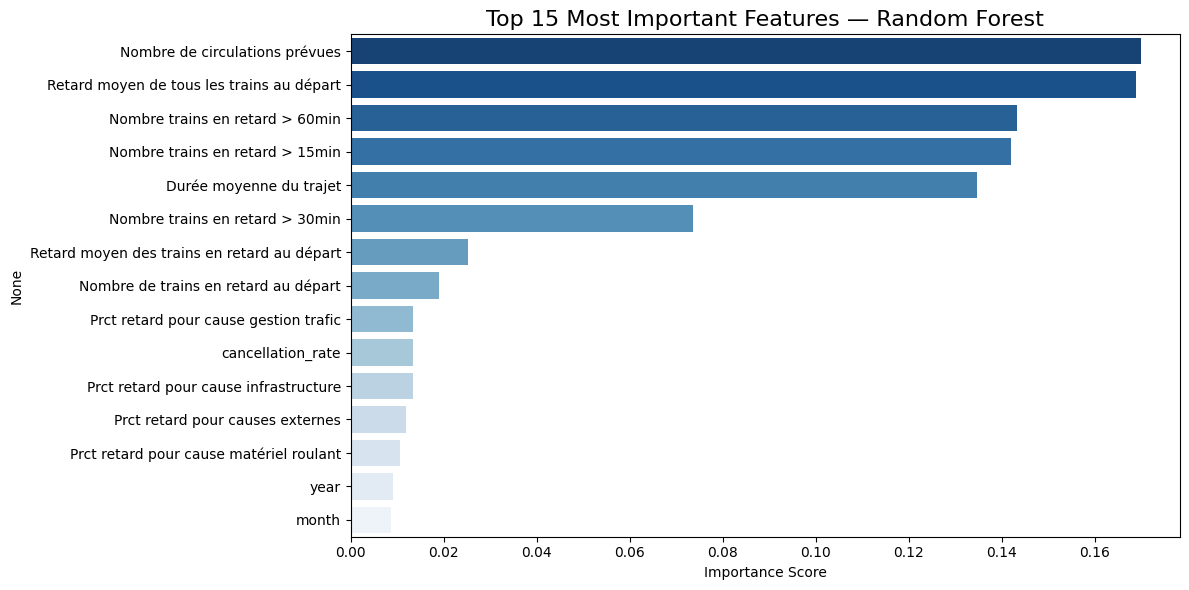

In [93]:
feature_names = X_rf.columns.tolist()
importances = pd.Series(rf.feature_importances_, index=feature_names)
top_features = importances.sort_values(ascending=False).head(15)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_features.values, y=top_features.index, palette="Blues_r")
plt.title("Top 15 Most Important Features — Random Forest", fontsize=16)
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()

In [94]:
joblib.dump(rf, "model.joblib")
joblib.dump(X_rf.columns.tolist(), "model_features.joblib")

['model_features.joblib']